# Practical Time Series Analysis. 
# Homework 4: Deep Learning Fundamentals & Transformers

---

## Instructions
Complete all sections of this assignment. Provide clear explanations for your code and results. Submit your completed notebook with all outputs visible.

---

## Part 1: Deep Learning Fundamentals

### 1. Neural Network Training Analysis

**Objective:** Analyze the training dynamics of neural networks and understand the effect of different hyperparameters.

#### 1.1 Create Dataset and Model
Use any dataset you want for regression analysis (you can use `make_regression` or load your own dataset):
- Create training (80%) and validation (20%) splits
- Create DataLoaders with batch size of 32
- Use the provided neural network architecture

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

import time

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
class SimpleNetwork(nn.Module):
    # Two hidden layers with ReLU activations - a standard MLP for regression
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        return x


# Creates a regression dataset, standardizes it, splits 80/20, wraps in DataLoaders
def create_simple_dataset(n_samples=3000, n_features=12, noise=20.0, random_state=SEED):
    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=8,
        noise=noise,
        random_state=random_state,
    )
    y = y.reshape(-1, 1)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    X_train = x_scaler.transform(X_train)
    X_val = x_scaler.transform(X_val)
    y_train = y_scaler.transform(y_train)
    y_val = y_scaler.transform(y_val)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    return train_loader, val_loader, n_features


train_loader, val_loader, n_features = create_simple_dataset()
print(f"Number of features: {n_features}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Number of features: 12
Train batches: 75, Val batches: 19


#### 1.2 Implement Training with Statistics Collection
Create a training function that collects the following statistics for each epoch:
- Training loss
- Validation loss
- Total gradient norm (L2 norm of all gradients combined)
- Total weight norm (L2 norm of all parameters combined)

In [3]:
def train_and_analyze(model, train_loader, val_loader, epochs=100, learning_rate=0.01, 
                      optimizer_cls=optim.Adam, verbose=False):
    """
    Train model and collect training statistics:
    - train_losses
    - val_losses
    - weight_norms (L2)
    - gradient_norms (L2)
    """
    criterion = nn.MSELoss()
    optimizer = optimizer_cls(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    weight_norms = []
    gradient_norms = []

    def total_grad_norm(model):
        total = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total += p.grad.detach().norm(2).item() ** 2
        return total ** 0.5

    def total_weight_norm(model):
        total = 0.0
        for p in model.parameters():
            total += p.detach().norm(2).item() ** 2
        return total ** 0.5

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_grad_norm = 0.0
        n_batches = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()

            running_grad_norm += total_grad_norm(model)
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches
        avg_grad_norm = running_grad_norm / n_batches
        weight_norm = total_weight_norm(model)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                val_running += criterion(preds, yb).item()
        val_loss = val_running / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        weight_norms.append(weight_norm)
        gradient_norms.append(avg_grad_norm)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"grad_norm={avg_grad_norm:.4f} weight_norm={weight_norm:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "weight_norms": weight_norms,
        "gradient_norms": gradient_norms,
        "model": model
    }

torch.manual_seed(SEED)
test_model = SimpleNetwork(n_features, hidden_size=32, output_size=1)
result = train_and_analyze(test_model, train_loader, val_loader, epochs=20, learning_rate=0.01, verbose=True)

Epoch  20/20 | train_loss=0.0089 val_loss=0.0091 grad_norm=0.2087 weight_norm=6.5125


#### 1.3 Learning Rate Analysis
Train the same model with three different learning rates: [0.001, 0.01, 0.1]
- For each learning rate, collect training statistics for 100 epochs
- Create a 2x2 subplot showing:
  - Top left: Training/validation loss curves for all learning rates
  - Top right: Gradient norms over time
  - Bottom left: Weight norms over time
  - Bottom right: Final validation loss for each learning rate (bar chart)

lr=0.001  final train_loss=0.0054 final val_loss=0.0079
lr=0.01   final train_loss=0.0064 final val_loss=0.0091
lr=0.1    final train_loss=0.0163 final val_loss=0.0106


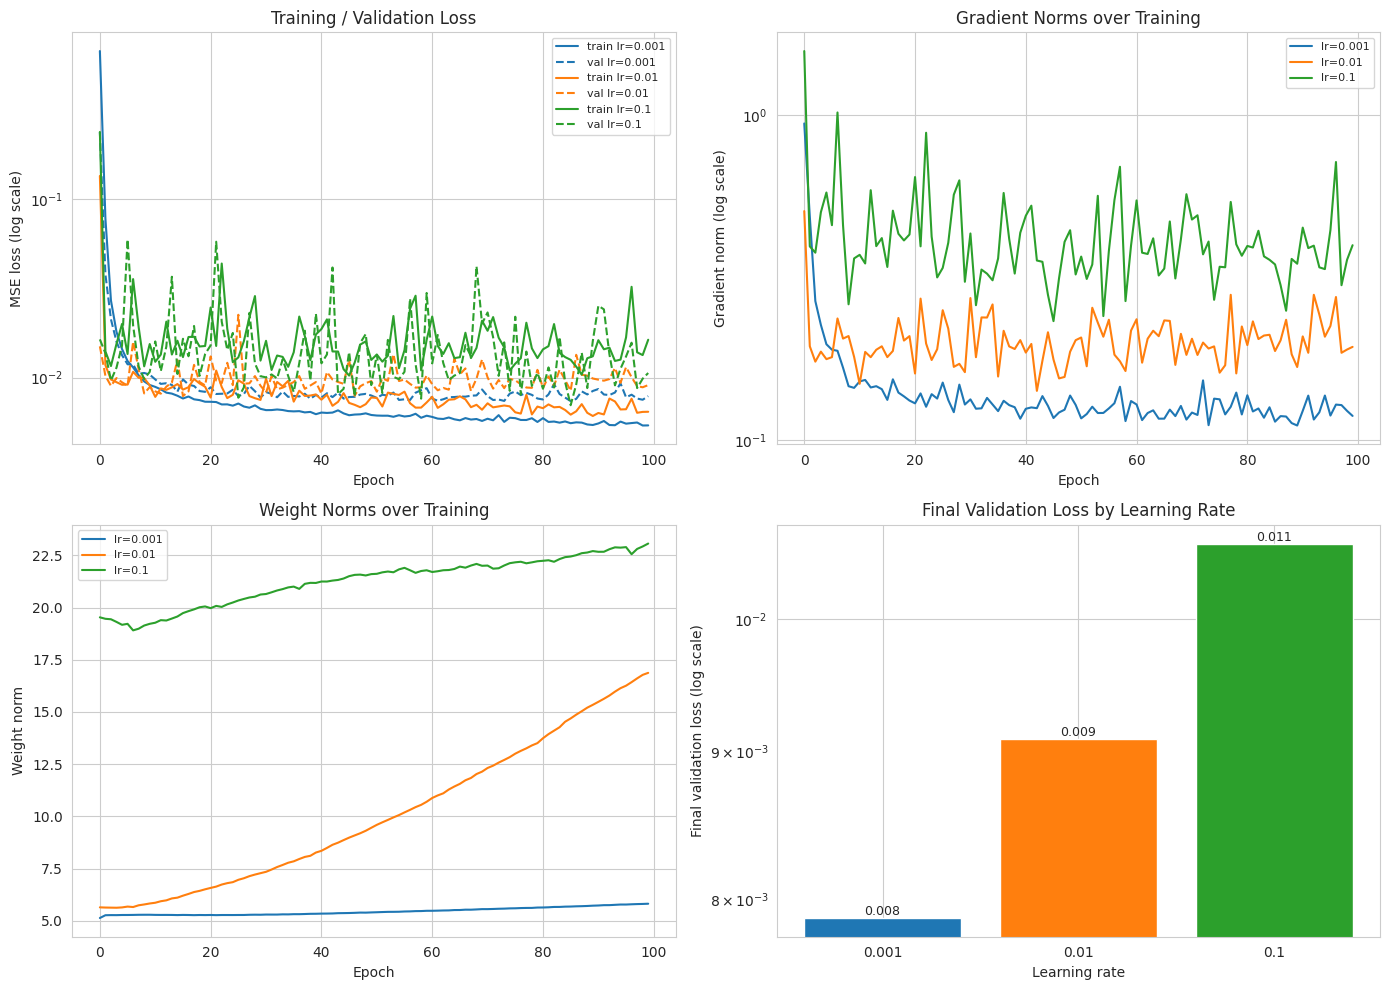

In [4]:
def analyze_training_dynamics():
    """Analyze different aspects of neural network training"""
    learning_rates = [0.001, 0.01, 0.1]
    epochs = 100
    results = {}

    for lr in learning_rates:
        torch.manual_seed(SEED)
        model = SimpleNetwork(n_features, hidden_size=32, output_size=1)
        res = train_and_analyze(model, train_loader, val_loader, epochs=epochs, learning_rate=lr)
        results[lr] = res
        print(f"lr={lr:<6} final train_loss={res['train_losses'][-1]:.4f} "
              f"final val_loss={res['val_losses'][-1]:.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = sns.color_palette("tab10", len(learning_rates))

    # train/val loss curves
    ax = axes[0, 0]
    for lr, color in zip(learning_rates, colors):
        ax.plot(results[lr]["train_losses"], color=color, linestyle="-", label=f"train lr={lr}")
        ax.plot(results[lr]["val_losses"], color=color, linestyle="--", label=f"val lr={lr}")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (log scale)")
    ax.set_title("Training / Validation Loss")
    ax.legend(fontsize=8)

    # gradient norms
    ax = axes[0, 1]
    for lr, color in zip(learning_rates, colors):
        ax.plot(results[lr]["gradient_norms"], color=color, label=f"lr={lr}")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Gradient norm (log scale)")
    ax.set_title("Gradient Norms over Training")
    ax.legend(fontsize=8)

    # weight norms
    ax = axes[1, 0]
    for lr, color in zip(learning_rates, colors):
        ax.plot(results[lr]["weight_norms"], color=color, label=f"lr={lr}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weight norm")
    ax.set_title("Weight Norms over Training")
    ax.legend(fontsize=8)

    # val loss bar chart
    ax = axes[1, 1]
    final_val = [results[lr]["val_losses"][-1] for lr in learning_rates]
    bars = ax.bar([str(lr) for lr in learning_rates], final_val, color=colors)
    ax.set_yscale("log")
    ax.set_xlabel("Learning rate")
    ax.set_ylabel("Final validation loss (log scale)")
    ax.set_title("Final Validation Loss by Learning Rate")
    for bar, val in zip(bars, final_val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    return results


lr_results = analyze_training_dynamics()

#### 1.4 Optimizer Comparison
Compare SGD and Adam optimizers:
- Train two identical models with the same learning rate (0.01)
- Plot training and validation curves for both optimizers
- Report which optimizer converges faster and achieves better final performance

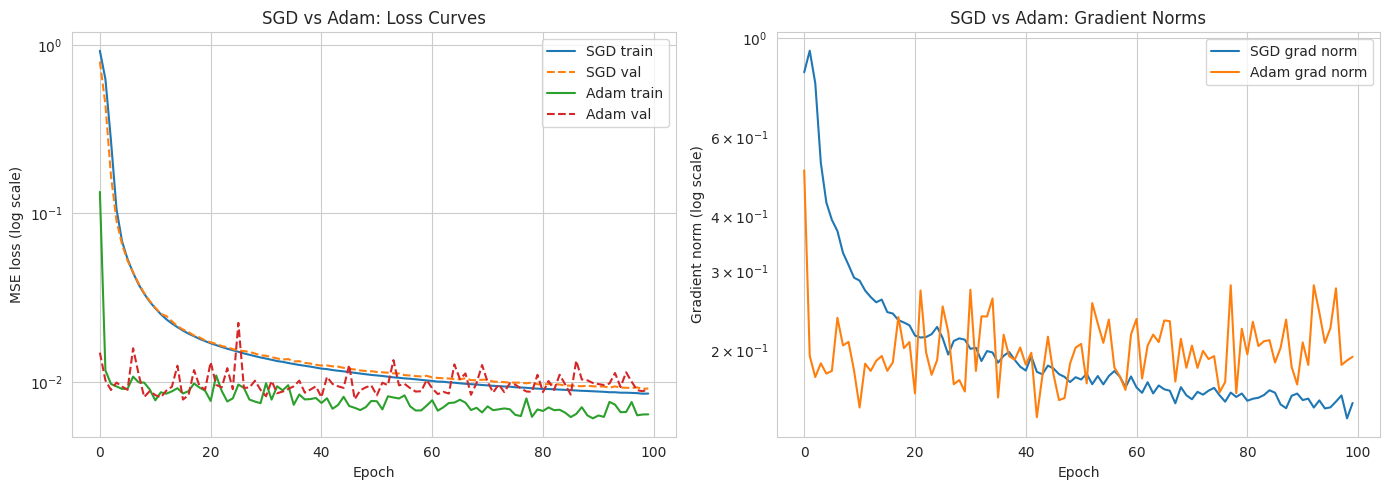

SGD  -> final train_loss=0.0086, final val_loss=0.0092
Adam -> final train_loss=0.0064, final val_loss=0.0091
SGD  reached near-final performance at epoch 72
Adam reached near-final performance at epoch 3


In [5]:
def compare_optimizers():
    """Compare different optimizers (SGD vs Adam)"""
    epochs = 100
    lr = 0.01

    torch.manual_seed(SEED)
    model_sgd = SimpleNetwork(n_features, hidden_size=32, output_size=1)
    res_sgd = train_and_analyze(model_sgd, train_loader, val_loader, epochs=epochs,
                                 learning_rate=lr, optimizer_cls=optim.SGD)

    torch.manual_seed(SEED)
    model_adam = SimpleNetwork(n_features, hidden_size=32, output_size=1)
    res_adam = train_and_analyze(model_adam, train_loader, val_loader, epochs=epochs,
                                  learning_rate=lr, optimizer_cls=optim.Adam)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(res_sgd["train_losses"], label="SGD train")
    ax.plot(res_sgd["val_losses"], label="SGD val", linestyle="--")
    ax.plot(res_adam["train_losses"], label="Adam train")
    ax.plot(res_adam["val_losses"], label="Adam val", linestyle="--")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (log scale)")
    ax.set_title("SGD vs Adam: Loss Curves")
    ax.legend()

    ax = axes[1]
    ax.plot(res_sgd["gradient_norms"], label="SGD grad norm")
    ax.plot(res_adam["gradient_norms"], label="Adam grad norm")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Gradient norm (log scale)")
    ax.set_title("SGD vs Adam: Gradient Norms")
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"SGD  -> final train_loss={res_sgd['train_losses'][-1]:.4f}, final val_loss={res_sgd['val_losses'][-1]:.4f}")
    print(f"Adam -> final train_loss={res_adam['train_losses'][-1]:.4f}, final val_loss={res_adam['val_losses'][-1]:.4f}")

    # Epoch where each optimizer first reaches within 10% of its own final val loss
    def epochs_to_converge(val_losses, tol=1.1):
        target = val_losses[-1] * tol
        for i, v in enumerate(val_losses):
            if v <= target:
                return i + 1
        return len(val_losses)

    print(f"SGD  reached near-final performance at epoch {epochs_to_converge(res_sgd['val_losses'])}")
    print(f"Adam reached near-final performance at epoch {epochs_to_converge(res_adam['val_losses'])}")

    return res_sgd, res_adam


res_sgd, res_adam = compare_optimizers()

**Questions:**


**1. How does learning rate affect the training process and convergence?**

The learning rate controls the step size during parameter updates. With `lr=0.001`, the model converges slowly but stably, and 100 epochs are often insufficient to reach a good optimum. At `lr=0.01`, convergence is faster while remaining stable. At `lr=0.1`, training becomes unstable: the loss and gradient norms show large spikes, and the weight norm shows a brief dip early in training rather than monotonic growth, unlike the smaller learning rates, indicating that the optimizer overshoots the minimum and struggles to settle.

**2. What do gradient norms tell us about the training process?**

Gradient norm reflects how fast the loss is changing with respect to the model parameters. Early in training, gradient norms are typically large because the model is far from the optimum. As training progresses and the model approaches a minimum, gradient norms should gradually decrease. Persistently high or spiky gradient norms (as seen with `lr=0.1`) indicate an unstable learning rate, while a very rapid collapse to near-zero can signal vanishing gradients or that the model has stopped learning effectively.

**3. Why might Adam converge faster than SGD in some cases?**

Unlike SGD, which uses a single fixed learning rate for all parameters, Adam adapts the step size individually for each parameter by combining momentum with second-moment estimates of the gradients. This allows Adam to take larger steps for parameters with small or sparse gradients and smaller steps for parameters with large gradients. As a result, Adam usually reaches good performance in fewer epochs than vanilla SGD, especially on noisy or ill-conditioned loss landscapes.


---

## Part 2: Time Series Forecasting Comparison

### 3. Time Series Model Comparison

Choose any time series dataset and train three different models: SARIMA, Prophet, and any Neural Network (transformer, LSTM, or simple NN). Compare their performance using cross-validation and create visualizations.


In [6]:
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

target_col = 'OT'
ts = df[target_col].astype(float)

print(f"Dataset: ETTh1 | Target: {target_col} | Shape: {df.shape}")

Dataset: ETTh1 | Target: OT | Shape: (17420, 7)


In [7]:
HORIZON = 24
N_FOLDS = 3
WINDOW = 168          # 7 days lookback
TRAIN_WINDOW = 3000   # ~125 days of history per fold 

# Rolling-window walk-forward splits
total_len = len(ts)
fold_splits = []
for k in range(N_FOLDS):
    test_end = total_len - HORIZON * (N_FOLDS - 1 - k)
    test_start = test_end - HORIZON
    train_start = max(0, test_start - TRAIN_WINDOW)
    fold_splits.append((train_start, test_start, test_end))

print(f"Number of folds: {len(fold_splits)}")

Number of folds: 3


In [8]:
def calculate_fold_metrics(preds_list, actuals_list):
    rmses, maes, mapes = [], [], []
    for p, a in zip(preds_list, actuals_list):
        p, a = np.asarray(p), np.asarray(a)
        rmses.append(np.sqrt(mean_squared_error(a, p)))
        maes.append(mean_absolute_error(a, p))
        mask = np.abs(a) > 1e-2
        mapes.append(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100 if mask.any() else np.nan)
    return rmses, maes, mapes

### Models

In [9]:
def run_sarima(train_series, horizon):
    try:
        model = SARIMAX(train_series, order=(2, 1, 2), seasonal_order=(1, 1, 1, 24),
                        enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res.forecast(steps=horizon).values
    except (np.linalg.LinAlgError, ValueError) as e:
        print(f"  [SARIMA] fit failed ({e!r}), falling back to last-value forecast")
        return np.full(horizon, train_series.iloc[-1])

def run_prophet(train_series, horizon):
    df_p = train_series.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(
        yearly_seasonality=False,      # disabled because training window is short
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        mcmc_samples=0                 
    )
    m.fit(df_p)
    future = m.make_future_dataframe(periods=horizon, freq='h')
    return m.predict(future)['yhat'].iloc[-horizon:].values

class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def make_windows(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    return np.array(X), np.array(y)

def run_gru(train_series, horizon, window=WINDOW, epochs=80, hidden_size=64, batch_size=128, lr=0.001):
    values = train_series.values.astype(float)
    mu, sigma = values.mean(), values.std()
    scaled = (values - mu) / sigma

    X, y = make_windows(scaled, window)
    if len(X) == 0:
        return np.full(horizon, train_series.iloc[-1])

    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    torch.manual_seed(SEED)
    model = GRUForecaster(hidden_size=hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # Recursive forecast
    model.eval()
    history = list(scaled[-window:])
    forecasts = []
    with torch.no_grad():
        for _ in range(horizon):
            x_in = torch.tensor(history[-window:], dtype=torch.float32).view(1, window, 1)
            next_val = model(x_in).item()
            forecasts.append(next_val)
            history.append(next_val)

    return np.array(forecasts) * sigma + mu


### Cross-validation

In [10]:
sarima_preds, sarima_actuals, sarima_times = [], [], []
prophet_preds, prophet_actuals, prophet_times = [], [], []
gru_preds, gru_actuals, gru_times = [], [], []

for fold_idx, (train_start, test_start, test_end) in enumerate(fold_splits):
    print(f"\n=== Fold {fold_idx + 1}/{len(fold_splits)} ===")
    train_series = ts.iloc[train_start:test_start]
    test_series = ts.iloc[test_start:test_end]

    # SARIMA
    t0 = time.time()
    pred = run_sarima(train_series, HORIZON)
    sarima_times.append(time.time() - t0)
    sarima_preds.append(pred)
    sarima_actuals.append(test_series.values)
    print(f"  SARIMA done in {sarima_times[-1]:.1f}s")

    # Prophet
    t0 = time.time()
    pred = run_prophet(train_series, HORIZON)
    prophet_times.append(time.time() - t0)
    prophet_preds.append(pred)
    prophet_actuals.append(test_series.values)
    print(f"  Prophet done in {prophet_times[-1]:.1f}s")

    # GRU
    t0 = time.time()
    pred = run_gru(train_series, HORIZON)
    gru_times.append(time.time() - t0)
    gru_preds.append(pred)
    gru_actuals.append(test_series.values)
    print(f"  GRU done in {gru_times[-1]:.1f}s")




=== Fold 1/3 ===
  SARIMA done in 44.1s


22:40:26 - cmdstanpy - INFO - Chain [1] start processing
22:40:27 - cmdstanpy - INFO - Chain [1] done processing


  Prophet done in 2.0s
  GRU done in 180.7s

=== Fold 2/3 ===


22:44:16 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA done in 47.5s


...

  Prophet done in 0.8s
  GRU done in 185.6s

=== Fold 3/3 ===


22:48:15 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA done in 52.7s


22:48:15 - cmdstanpy - INFO - Chain [1] done processing


  Prophet done in 0.7s
  GRU done in 186.0s


In [11]:
sarima_rmse, sarima_mae, sarima_mape = calculate_fold_metrics(sarima_preds, sarima_actuals)
prophet_rmse, prophet_mae, prophet_mape = calculate_fold_metrics(prophet_preds, prophet_actuals)
gru_rmse, gru_mae, gru_mape = calculate_fold_metrics(gru_preds, gru_actuals)

results_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "GRU"],
    "Mean RMSE": [np.mean(sarima_rmse), np.mean(prophet_rmse), np.mean(gru_rmse)],
    "Mean MAE": [np.mean(sarima_mae), np.mean(prophet_mae), np.mean(gru_mae)],
    "Mean MAPE (%)": [np.nanmean(sarima_mape), np.nanmean(prophet_mape), np.nanmean(gru_mape)],
    "Avg Time per Fold (s)": [np.mean(sarima_times), np.mean(prophet_times), np.mean(gru_times)]
})

print("\n" + "="*60)
print("FINAL RESULTS ON ETTh1 (OT)")
print("="*60)
print(results_df.round(3))
print("\nBest model by accuracy (RMSE):", results_df.loc[results_df['Mean RMSE'].idxmin(), 'Model'])
print("Fastest model:                  ", results_df.loc[results_df['Avg Time per Fold (s)'].idxmin(), 'Model'])




FINAL RESULTS ON ETTh1 (OT)
     Model  Mean RMSE  Mean MAE  Mean MAPE (%)  Avg Time per Fold (s)
0   SARIMA      0.959     0.781          8.092                 48.073
1  Prophet      0.892     0.746          8.258                  1.199
2      GRU      1.205     1.002         10.959                184.088

Best model by accuracy (RMSE): Prophet
Fastest model:                   Prophet


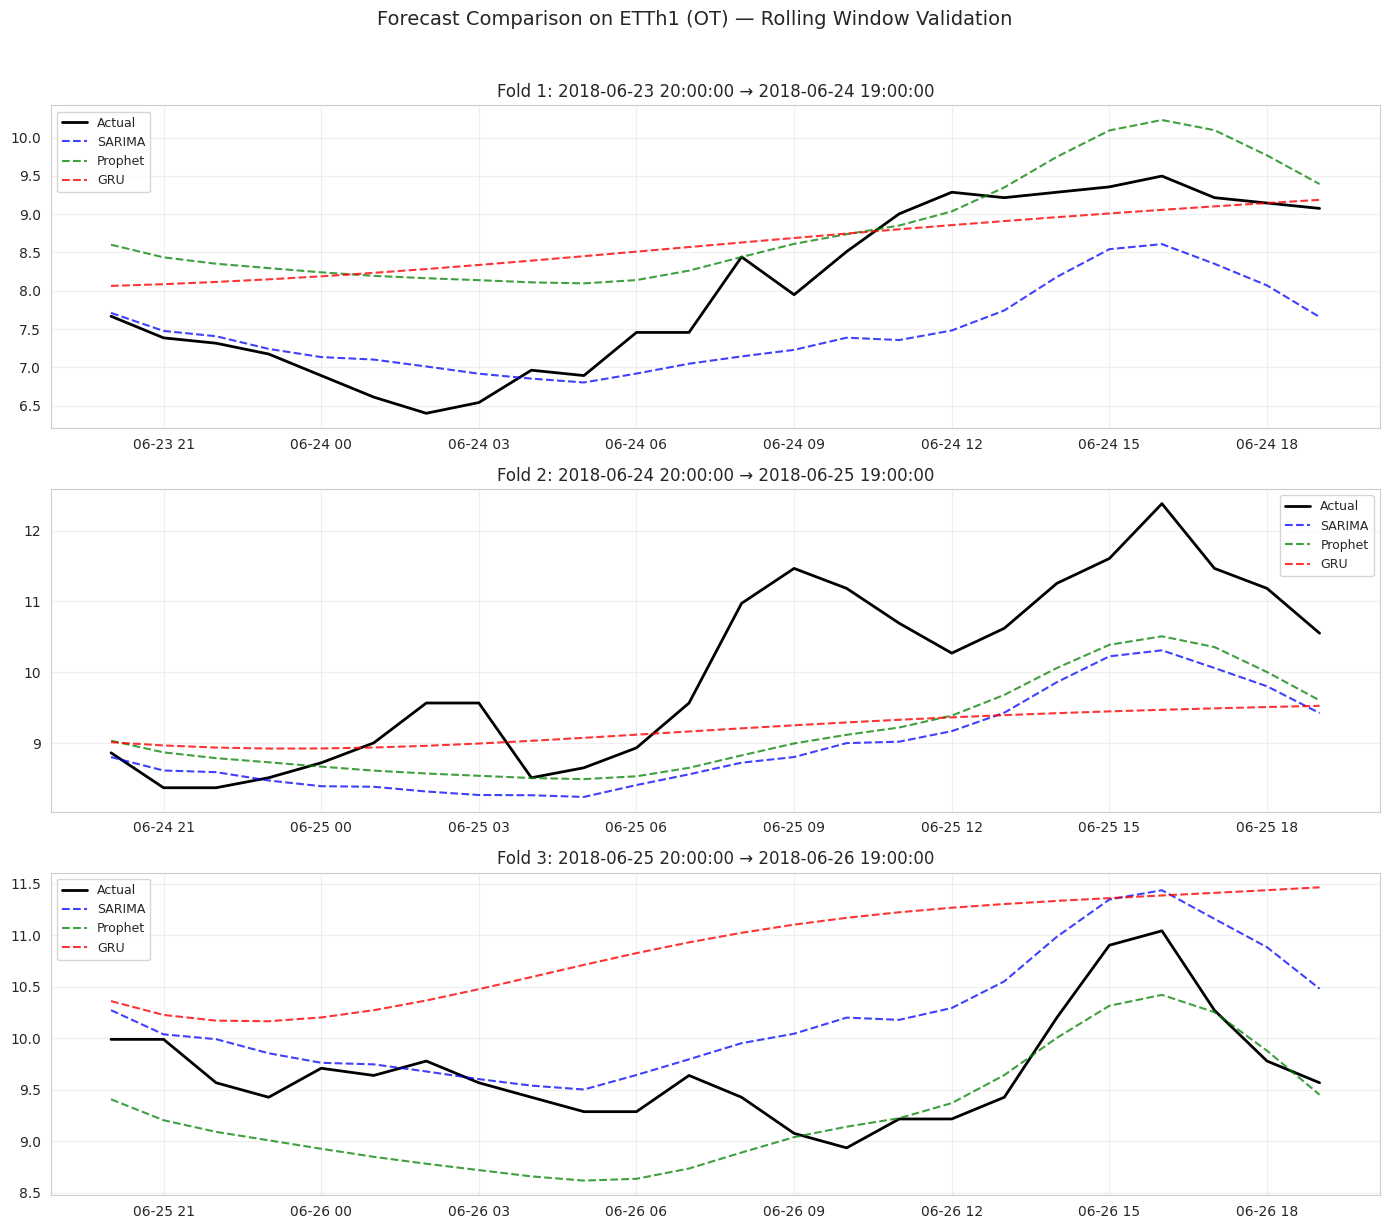

In [12]:
fig, axes = plt.subplots(len(fold_splits), 1, figsize=(14, 4 * len(fold_splits)), sharex=False)

for i, (train_start, test_start, test_end) in enumerate(fold_splits):
    ax = axes[i] if len(fold_splits) > 1 else axes
    test_idx = ts.index[test_start:test_end]
    
    ax.plot(test_idx, sarima_actuals[i], 'k-', label='Actual', linewidth=2)
    ax.plot(test_idx, sarima_preds[i], 'b--', label='SARIMA', alpha=0.75)
    ax.plot(test_idx, prophet_preds[i], 'g--', label='Prophet', alpha=0.75)
    ax.plot(test_idx, gru_preds[i], 'r--', label='GRU', alpha=0.8)
    
    ax.set_title(f"Fold {i+1}: {test_idx[0]} → {test_idx[-1]}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Forecast Comparison on ETTh1 (OT) — Rolling Window Validation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Questions:**

**4. Which model performed best on your dataset and why?**

**Prophet** achieved the best results on ETTh1, with the lowest mean RMSE (0.892) and MAE (0.746). This is mainly because the dataset contains strong daily and weekly seasonality, which Prophet handles effectively through its additive decomposition. Note that Prophet's advantage is mainly driven by Fold 2, where it tracks the large peak (≈12.4) more closely than SARIMA and GRU; in Fold 3, SARIMA actually follows the actual series more closely than Prophet. The GRU performed worse, primarily due to error accumulation during recursive multi-step forecasting over the 24-hour horizon. It is also important to note that the GRU was trained in a purely univariate setting (using only the OT series), whereas standard benchmarks on ETTh1 typically use additional covariates.

**5. How do the computational requirements compare between the three approaches?**

Prophet was significantly faster than the other models, averaging only about 1.2 seconds per fold. SARIMA was much slower (48 seconds per fold) due to the high computational cost of fitting models with a 24-hour seasonal component. The GRU was the slowest (184 seconds per fold), as it required training a neural network from scratch for 80 epochs on every fold.

**6. What are the advantages and disadvantages of each forecasting method?**

- **SARIMA**: Strong theoretical foundation and works well with seasonal data, but scales poorly with long series and high seasonal periods.
- **Prophet**: Easy to use, automatically handles multiple seasonalities, and provides fast predictions. However, it is less effective on highly non-linear time series.
- **GRU**: Capable of learning complex temporal patterns, but suffers from high training time and error accumulation in recursive long-horizon forecasting.

**7. How does the choice of cross-validation strategy affect the model comparison results?**

The rolling-window strategy with a fixed training size ensured a fair comparison, as all models used the same amount of recent data in each fold. However, this limited the data available for the GRU, which generally benefits from larger training sets. An expanding-window approach could have improved GRU performance but would have made SARIMA prohibitively slow. Additionally, the 24-hour forecast horizon increased the impact of error accumulation in the GRU’s recursive predictions.

